# A first look at gas-turbine emissions data

**MECE 4520 · Fall 2026 · asynchronous foundations**

<a target="_blank" href="https://colab.research.google.com/github/changyaochen/MECE4520/blob/master/site/foundations/02-gas-turbine-data.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/>
</a>

This notebook introduces our primary recurring dataset. Before fitting a model, engineers should understand what was measured, what each observation represents, and which patterns are plausible.

**Learning objectives**

- Inspect a dataset for size, variable types, and missing values.
- Summarize measurements with appropriate descriptive statistics.
- Use plots to ask physical questions about a system.
- Distinguish an observed association from a causal conclusion.

## 1. Load the data

The UCI dataset contains 36,733 hourly observations from a gas turbine, measured between 2011 and 2015. Its rows are chronologically ordered, although individual timestamps are not supplied.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from urllib.request import urlretrieve

plt.style.use("seaborn-v0_8-whitegrid")

DATA_URL = (
    "https://raw.githubusercontent.com/changyaochen/MECE4520/master/"
    "site/data/gas-turbine-emissions.csv"
)
data_path = next(
    (path for path in [Path("../data/gas-turbine-emissions.csv"), Path("site/data/gas-turbine-emissions.csv"), Path("gas-turbine-emissions.csv")] if path.exists()),
    Path("gas-turbine-emissions.csv"),
)
if not data_path.exists():
    urlretrieve(DATA_URL, data_path)
data = pd.read_csv(data_path)
data.head()

,AT,AP,AH,AFDP,GTEP,TIT,TAT,TEY,CDP,CO,NOX
0,4.5878,1018.7,83.675,3.5758,23.979,1086.2,549.83,134.67,11.898,0.32663,81.952
1,4.2932,1018.3,84.235,3.5709,23.951,1086.1,550.05,134.67,11.892,0.44784,82.377
2,3.9045,1018.4,84.858,3.5828,23.990,1086.5,550.19,135.10,12.042,0.45144,83.776
3,3.7436,1018.3,85.434,3.5808,23.911,1086.5,550.17,135.03,11.990,0.23107,82.505
4,3.7516,1017.8,85.182,3.5781,23.917,1085.9,550.00,134.67,11.910,0.26747,82.028


## 2. What is in the table?

Each row is an hourly operating observation. Variables include ambient conditions, pressure and temperature measurements, turbine energy yield, and the emissions outcomes CO and NOx.

In [2]:
print(f"Observations: {data.shape[0]:,}")
print(f"Variables: {data.shape[1]}")

summary = pd.DataFrame({
    "dtype": data.dtypes.astype(str),
    "missing": data.isna().sum(),
    "unique values": data.nunique(),
})
summary

Observations: 36,733
Variables: 11


,dtype,missing,unique values
AT,float64,0,22523
AP,float64,0,791
AH,float64,0,25708
AFDP,float64,0,20495
GTEP,float64,0,12967
TIT,float64,0,799
TAT,float64,0,2769
TEY,float64,0,6236
CDP,float64,0,4447
CO,float64,0,26185


There are no missing values in this version of the dataset. That is convenient for teaching, but it should not be treated as normal: checking missingness is an essential first step in every real analysis.

## 3. Summarize key measurements

The mean alone is rarely enough. The standard deviation and quantiles describe how much a measurement varies across observed operating conditions.

In [3]:
key_variables = ["AT", "AP", "AH", "TIT", "TEY", "CO", "NOX"]
data[key_variables].describe().T[["mean", "std", "min", "25%", "50%", "75%", "max"]]

,mean,std,min,25%,50%,75%,max
AT,17.712726,7.447451,-6.234800,11.7810,17.8010,23.6650,37.103
AP,1013.070165,6.463346,985.850000,1008.8000,1012.6000,1017.0000,1036.600
AH,77.867015,14.461355,24.085000,68.1880,80.4700,89.3760,100.200
TIT,1081.428084,17.536373,1000.800000,1071.8000,1085.9000,1097.0000,1100.900
TEY,133.506404,15.618634,100.020000,124.4500,133.7300,144.0800,179.500
CO,2.372468,2.262672,0.000388,1.1824,1.7135,2.8429,44.103
NOX,65.293067,11.678357,25.905000,57.1620,63.8490,71.5480,119.910


## 4. Distribution of an emissions outcome

A histogram shows how frequently a range of values occurs. The distribution of NOx is not perfectly symmetric, so reporting only a mean can hide useful information about high-emission observations.

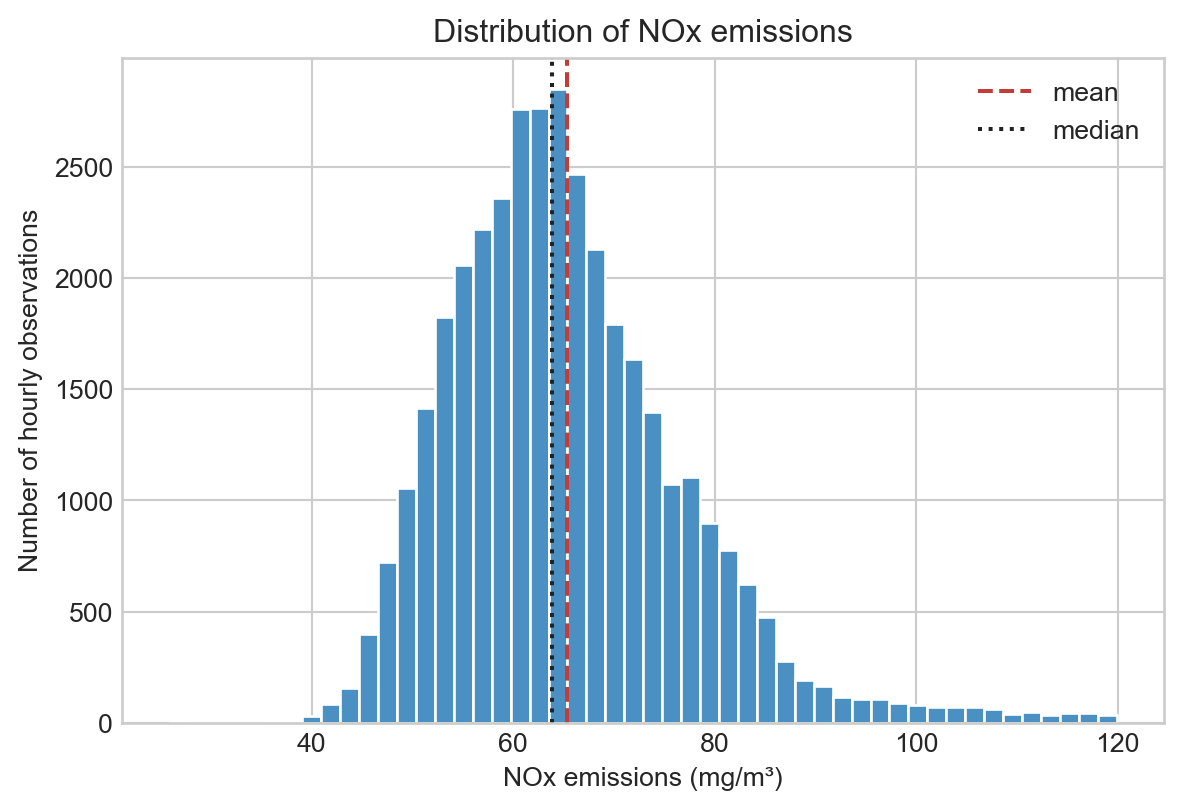

In [4]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(data["NOX"], bins=50, color="#4a90c2", edgecolor="white")
ax.axvline(data["NOX"].mean(), color="#c43c35", linestyle="--", label="mean")
ax.axvline(data["NOX"].median(), color="#222222", linestyle=":", label="median")
ax.set(xlabel="NOx emissions (mg/m³)", ylabel="Number of hourly observations", title="Distribution of NOx emissions")
ax.legend()
plt.show()

## 5. Explore associations

A correlation table is a compact overview of linear associations. It is useful for asking questions, not for deciding that one variable causes another. Sensors can be related because they respond to the same operating state.

In [5]:
correlations = data[key_variables].corr(numeric_only=True)
correlations.round(2)

,AT,AP,AH,TIT,TEY,CO,NOX
AT,1.00,-0.41,-0.48,0.18,-0.09,-0.17,-0.56
AP,-0.41,1.00,-0.02,-0.01,0.12,0.07,0.19
AH,-0.48,-0.02,1.00,-0.22,-0.14,0.11,0.16
TIT,0.18,-0.01,-0.22,1.00,0.91,-0.71,-0.21
TEY,-0.09,0.12,-0.14,0.91,1.00,-0.57,-0.12
CO,-0.17,0.07,0.11,-0.71,-0.57,1.00,0.34
NOX,-0.56,0.19,0.16,-0.21,-0.12,0.34,1.00


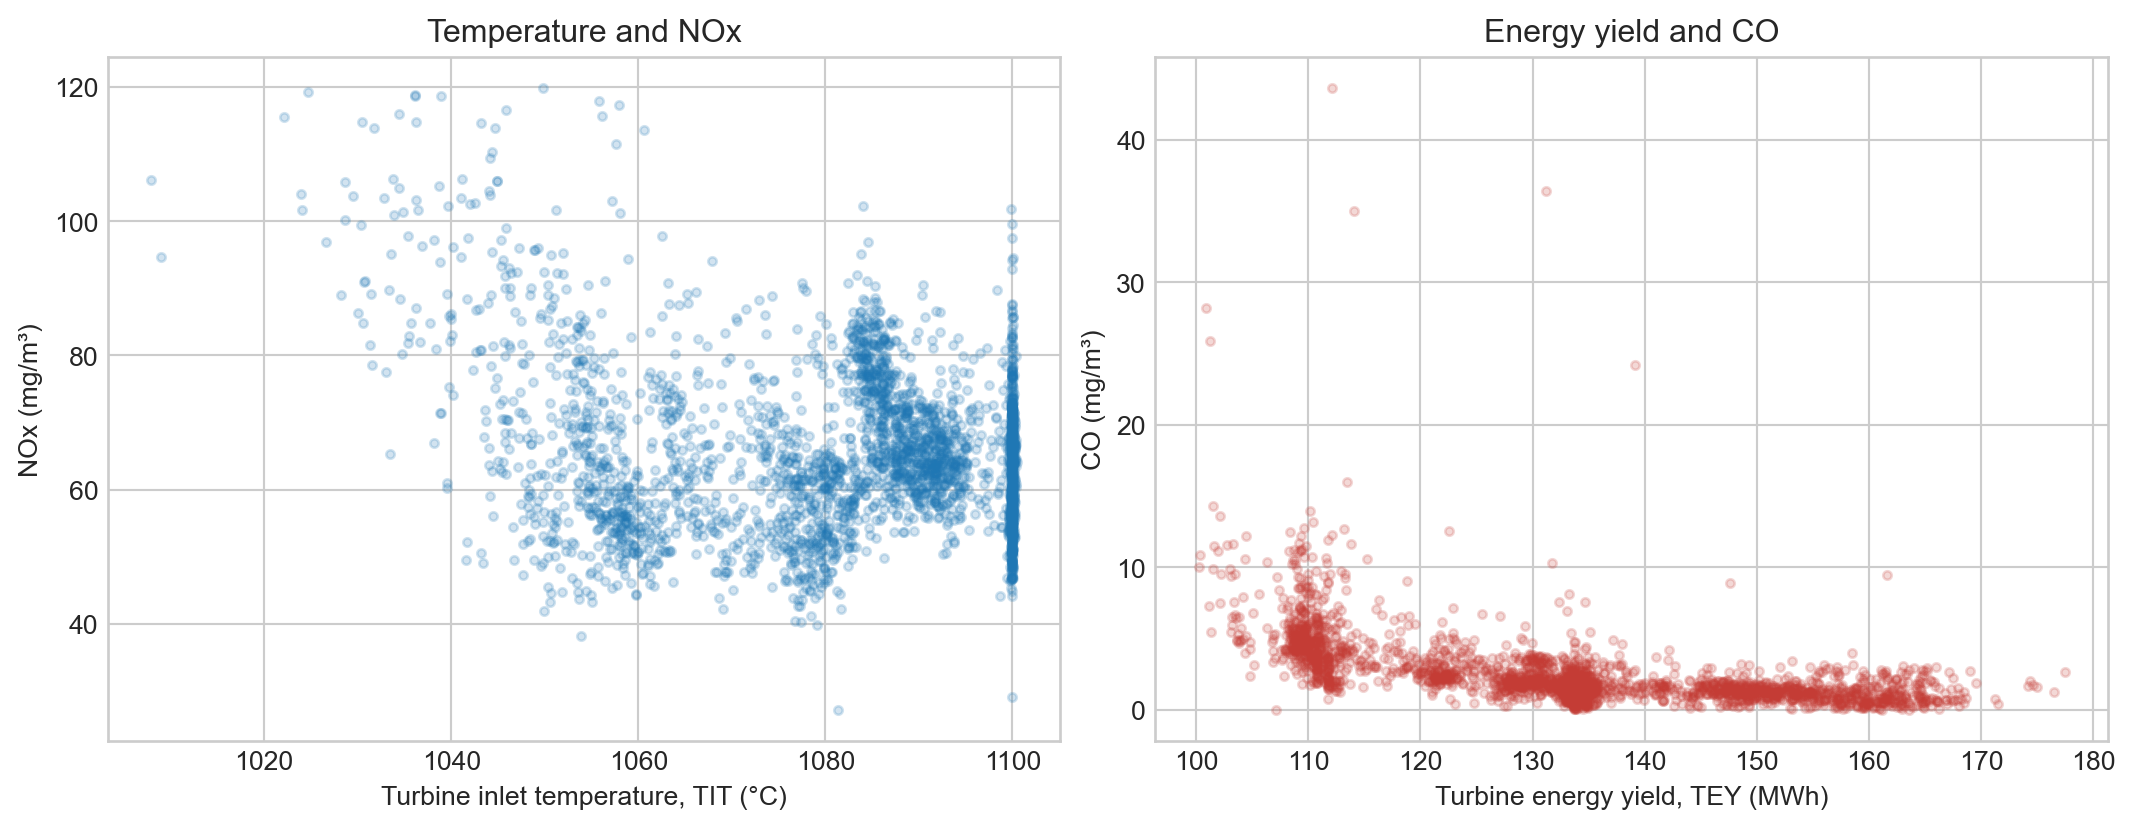

In [6]:
plot_data = data.sample(n=3_000, random_state=4520)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)
axes[0].scatter(plot_data["TIT"], plot_data["NOX"], alpha=0.2, s=10)
axes[0].set(xlabel="Turbine inlet temperature, TIT (°C)", ylabel="NOx (mg/m³)", title="Temperature and NOx")

axes[1].scatter(plot_data["TEY"], plot_data["CO"], alpha=0.2, s=10, color="#c43c35")
axes[1].set(xlabel="Turbine energy yield, TEY (MWh)", ylabel="CO (mg/m³)", title="Energy yield and CO")

plt.show()

## Check-in

1. Which variable has the most obvious association with NOx in the plots or correlation table?
2. What operating conditions might create a relationship between two sensors even if neither directly causes the other?
3. Why might chronology matter when we later split these observations into training and test sets?

Keep your answers in your own notes. The next notebook uses the same measurements to study variability and statistical evidence.

[Return to the Foundations page](index.qmd)